
我們用vit做分類器分類貓狗

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from transformers import AutoImageProcessor, ViTModel

/Users/jim/anaconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_name = "google/vit-base-patch16-224-in21k"
processor = AutoImageProcessor.from_pretrained(vit_name) #processor 會自動處理圖像的預處理步驟，例如調整大小、裁剪、標準化等，確保圖像符合 ViT 模型的輸入要求。
vit = ViTModel.from_pretrained(vit_name).to(device) 

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1944.94it/s, Materializing param=pooler.dense.weight]                              


In [4]:
import torch.nn.functional as F

class ViTClassifier(nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit
        self.fc1 = nn.Linear(vit.config.hidden_size, 128)
        self.classifier = nn.Linear(128, 10)  # 10 是 MNIST 的類別數量

    def forward(self, x):
        out = self.vit(pixel_values=x)
        cls_out = out.last_hidden_state[:, 0, :]
        x = F.relu(self.fc1(cls_out))
        out = self.classifier(x)
        return out


In [10]:
# 建議把 MNIST 的 transform 拿掉，保留 PIL image
train_ds = datasets.MNIST(root="data", train=True, download=True, transform=None)#資料型態是set
test_ds = datasets.MNIST(root="data", train=False, download=True, transform=None)

def collate_fn(batch):
    images = [item[0] for item in batch]   # PIL images
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    
    images = [img.convert("RGB") for img in images]
    proc = processor(images=images, return_tensors="pt")
    return proc["pixel_values"], labels

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 1875
Number of testing batches: 313


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


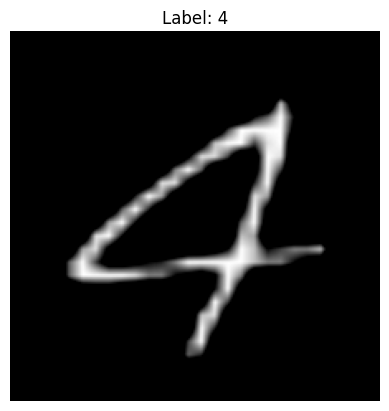

In [11]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))  # 直接拿第一個 batch
i = 0  # batch 裡第幾張

img = images[i].permute(1, 2, 0).cpu().numpy()
plt.imshow(img)
plt.title(f"Label: {labels[i].item()}")
plt.axis("off")
plt.show()

In [17]:
model = ViTClassifier(vit).to(device)
# 凍結 backbone（只訓練 fc1 + classifier）
for p in model.vit.parameters():
    p.requires_grad = False
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5,weight_decay=0.01)

In [18]:
model.train()
correct = 0
total = 0
loss_total = 0
i = 0
for x , y in train_loader: 
    i += 1
    if i > 100: break # 限制訓練批次數，避免過長訓練時間
    x = x.to(device)
    y = y.to(device)
    logits = model(x)
    pred = logits.argmax(dim=-1)#dim=-1 表示在最後一個維度上取最大值的索引，這裡是類別的索引，agarmax 是位子
    correct += (pred == y).sum().item() #計算正確預測
    total += y.size(0) #計算總樣本數
    loss = criterion(logits, y) #計算損失
    loss_total += loss.item() #累加損失
    optimizer.zero_grad() #清除之前的梯度
    loss.backward() #反向傳播計算梯度
    optimizer.step() #更新模型參數
print(f"Training Accuracy: {correct/total:.4f}, Loss: {loss_total/len(train_loader):.4f}")

Training Accuracy: 0.1828, Loss: 0.1216


In [16]:
model.eval()
correct = 0
total = 0
for x , y in test_loader:
    x = x.to(device)
    y = y.to(device)
    logits = model(x)
    pred = logits.argmax(dim=-1)
    correct += (pred == y).sum().item()
    total += y.size(0)
print(f"Testing Accuracy: {correct/total:.4f}")

KeyboardInterrupt: 